##Califorina Home Price Prediction

Alia Alami


In [ ]:
# import libraries for data manipulation
import pandas as pd
import numpy as np

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import ProbPlot

# import libraries for building linear regression model
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# import library for preparing data
from sklearn.model_selection import train_test_split

# import library for data preprocessing
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import requests
import pandas as pd
from io import StringIO

orig_url="https://drive.google.com/file/d/1Btewck_WuX41RQvVItWa220JWRGRDMpo/view?usp=drive_link"

file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text
csv_raw = StringIO(url)
df = pd.read_csv(csv_raw)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


total bedroms has 207 missing values

In [ ]:

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20640.0,536.838857,419.391878,1.0000,297.0000,435.0000,643.25000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


Observations:

Half of the regions have longitudes between -121.8 and -118.01 and latitudes between 33.93 and 37.71, indicating most observations are clustered in central California areas.

Half of the regions have housing median ages between 18 and 37 years, suggesting most neighborhoods are moderately aged rather than new or very old.

Fifty percent of regions have between 1,447 and 3,148 total rooms, with a typical value around 2,127 rooms, though extreme values reach over 39,000, indicating strong outliers.

Fifty percent of regions have between 296 and 644 bedrooms.

Fifty percent of regions have populations between 787 and 1,725, indicating most neighborhoods are moderately populated, though some extreme values exceed 35,000.

Fifty percent of regions have between 280 and 605 households, with a typical value around 409 households, reflecting average-sized communities.

Fifty percent of regions have median incomes between 2.56 and 4.74, with a typical value of 3.53, showing moderate but meaningful variation in income levels.

The distribution of median income is fairly spread out, ranging from 0.5 to 15, suggesting income is likely an important factor influencing housing prices.

Median house value is the target variable for this analysis. Values range from $14,999 to $500,001, with half of the observations between $119,600 and $264,725, and a typical value around $179,700, indicating a wide and right-skewed distribution.

The maximum house value appears capped at $500,001, which may limit the models ability to accurately predict higher-priced homes.

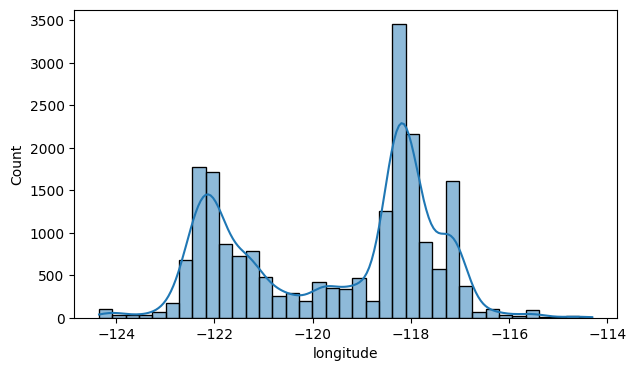

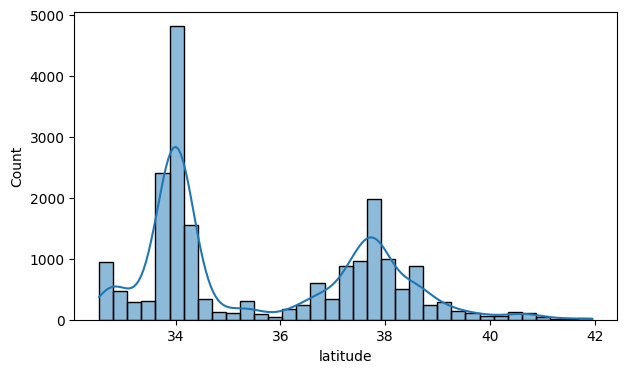

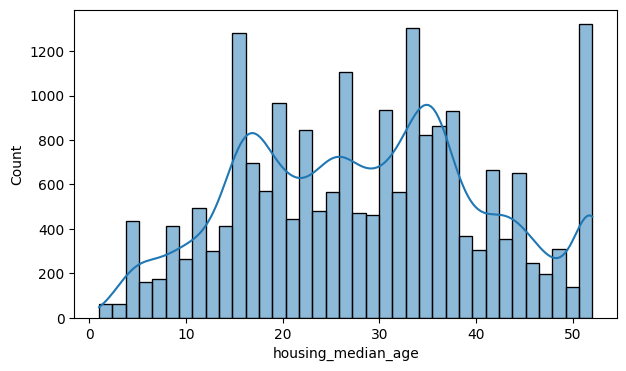

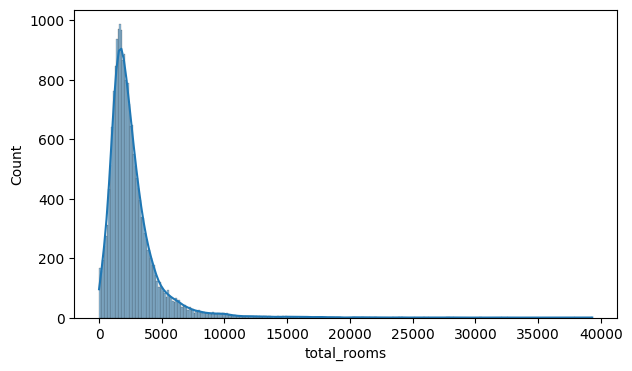

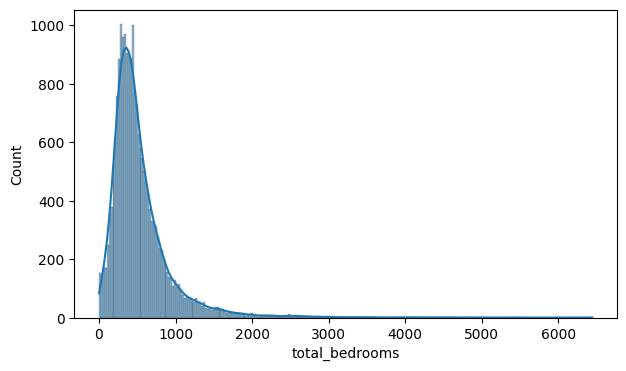

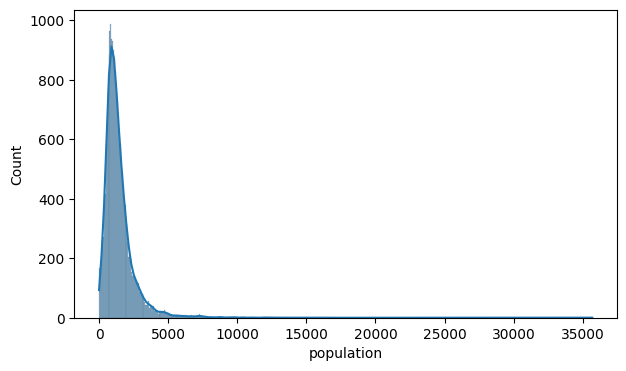

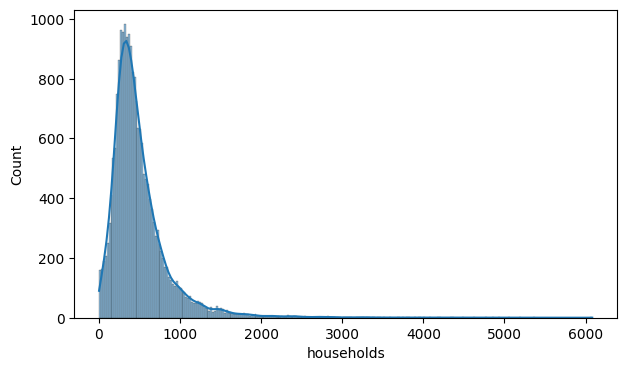

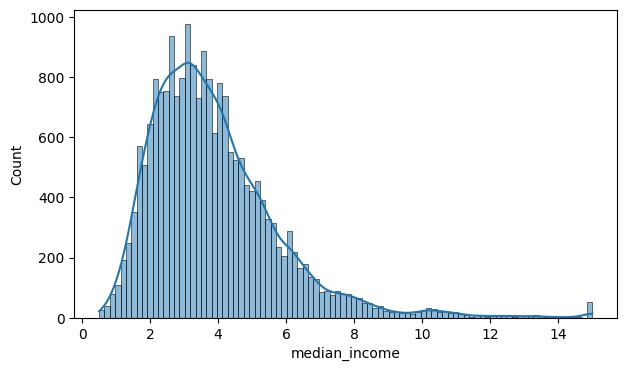

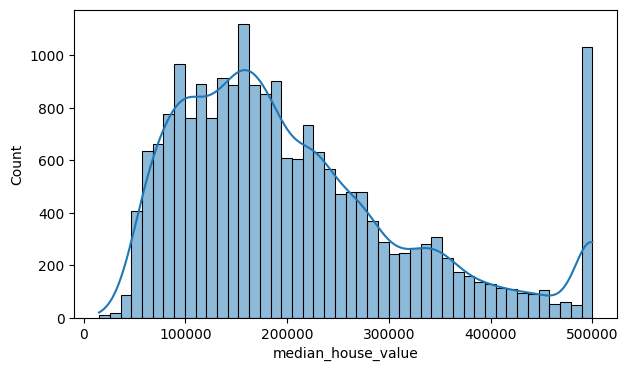

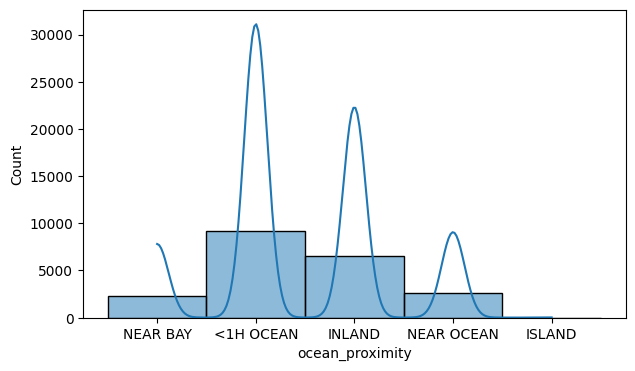

In [ ]:
for i in df.columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=i, kde = True)
    plt.show()

Longitude and latitude show clear clustering

Housing median age is fairly evenly distributed

Total rooms, total bedrooms, population, and households are all heavily right-skewed, with most values small but a few extreme outliers

Median income is slightly right-skewed, with most values between 2 and 6, and a few high-income outliers

Median house value is right-skewed and capped at $500,000, indicating limited representation of very high-value homes

Bedrooms per room is slightly right-skewed, suggesting most homes are not overcrowded, but some extreme cases exist

Rooms per household and population per household show extreme outliers, indicating unusual or potentially anomalous living conditions in a small number of regions

Ocean proximity is a categorical variable, with most observations falling into INLAND and <1H OCEAN, suggesting these are the dominant region types

In [ ]:
df['total_rooms'] = np.log1p(df['total_rooms'])
df['total_bedrooms'] = np.log1p(df['total_bedrooms'])
df['population'] = np.log1p(df['population'])
df['households'] = np.log1p(df['households'])

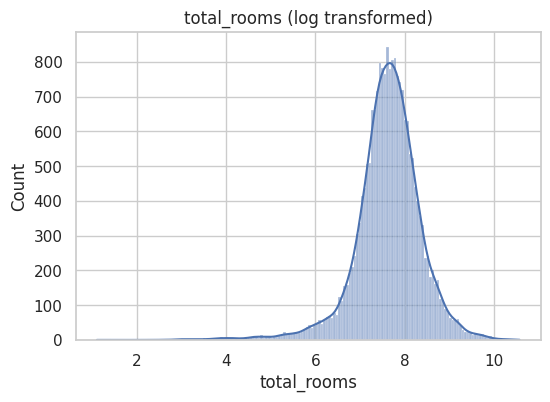

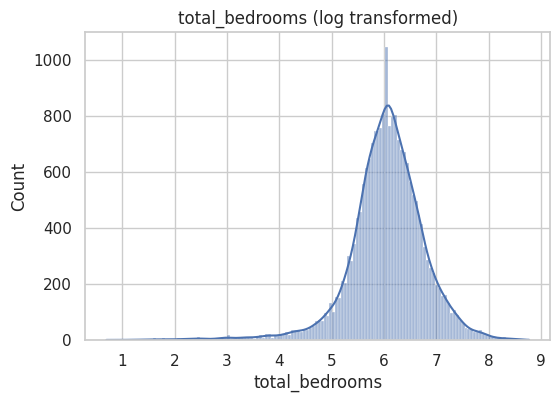

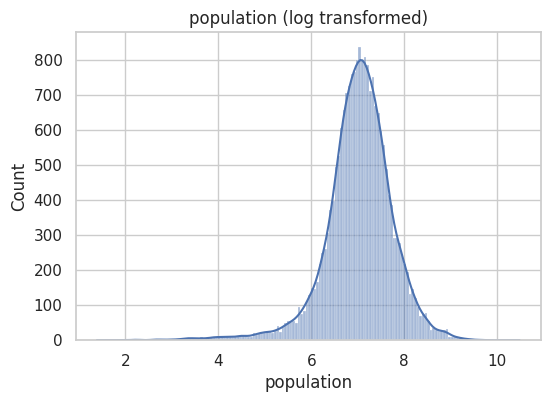

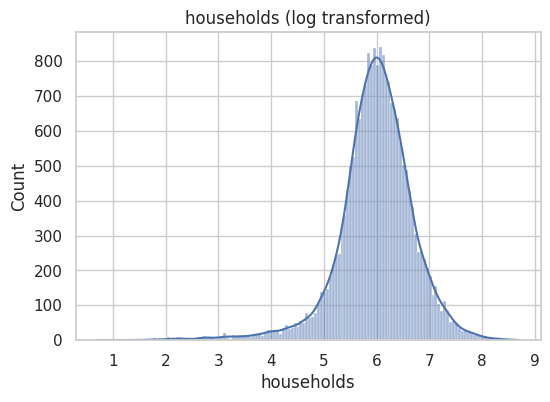

In [ ]:
cols = ['total_rooms', 'total_bedrooms', 'population', 'households']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} (log transformed)")
    plt.show()

Log transformation reduced skewness and outliers, creating more normally distributed variables

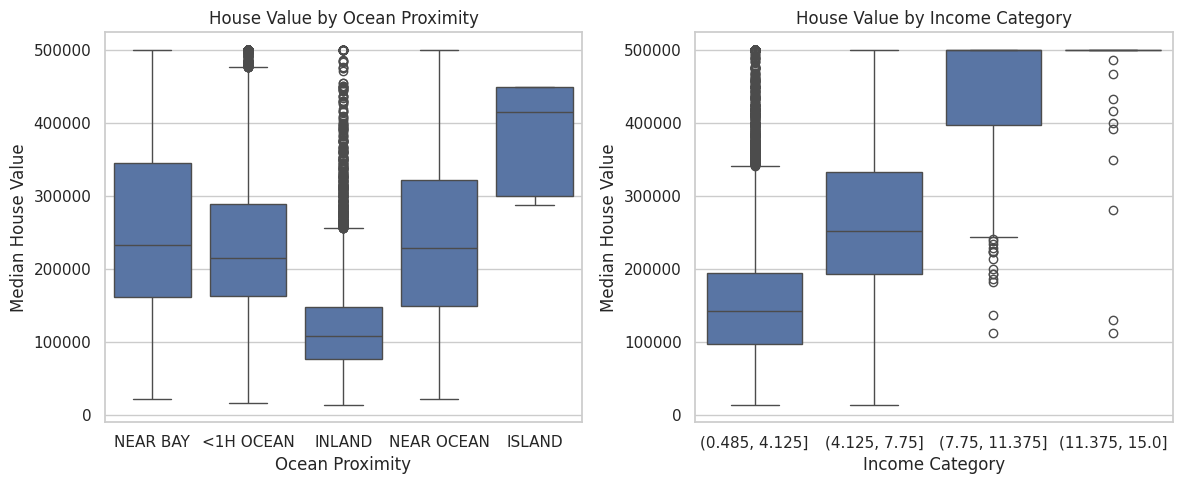

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, ax=axes[0])
axes[0].set_title('House Value by Ocean Proximity')
axes[0].set_xlabel('Ocean Proximity')
axes[0].set_ylabel('Median House Value')


df['income_cat'] = pd.cut(df['median_income'], bins=4)

sns.boxplot(x='income_cat', y='median_house_value', data=df, ax=axes[1])
axes[1].set_title('House Value by Income Category')
axes[1].set_xlabel('Income Category')
axes[1].set_ylabel('Median House Value')

plt.tight_layout()
plt.show()

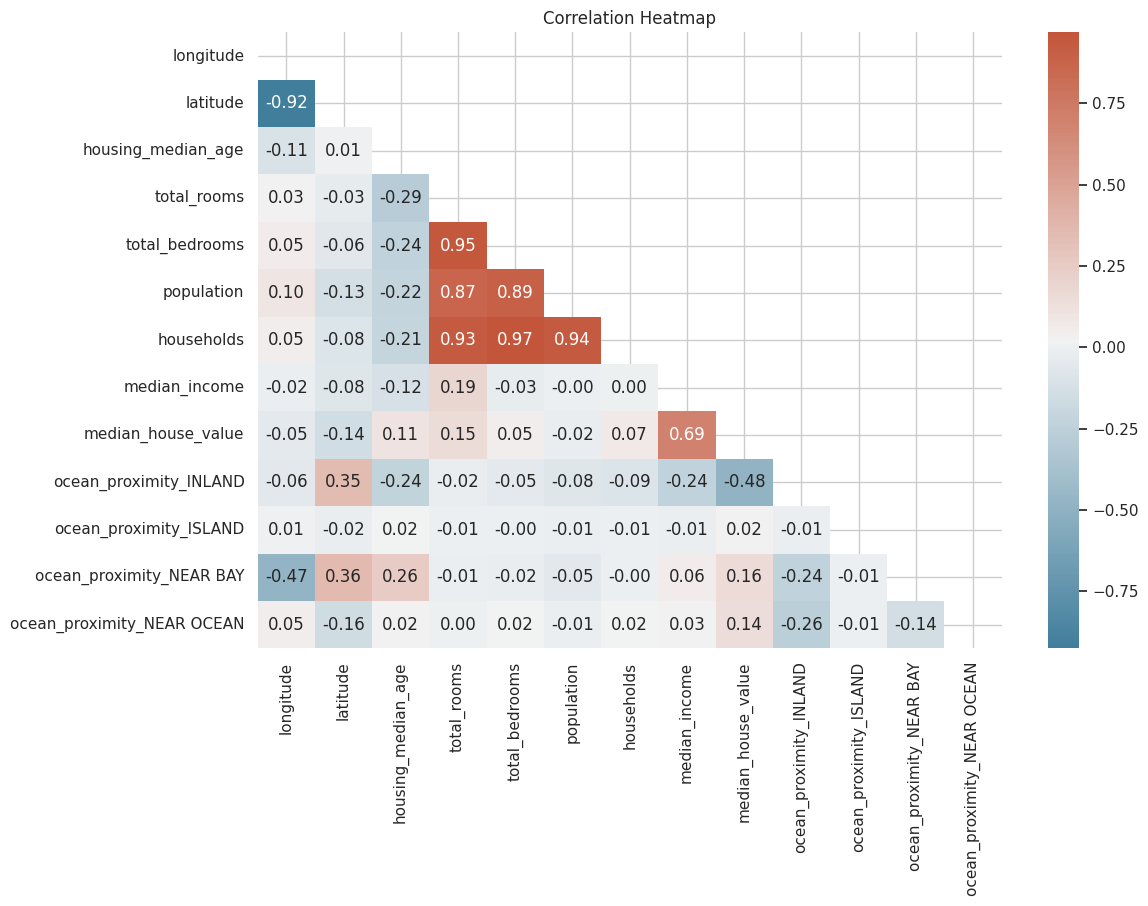

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, mask=mask)

plt.title("Correlation Heatmap")
plt.show()

Observations:

Positive correlations of note are observed between:

median_income and median_house_value

total_rooms and total_bedrooms

total_rooms and households

total_bedrooms and households

population and households

Negative correlations of note are observed between:

latitude and median_house_value

bedrooms_per_room and median_house_value

housing_median_age and total_rooms

population and latitude

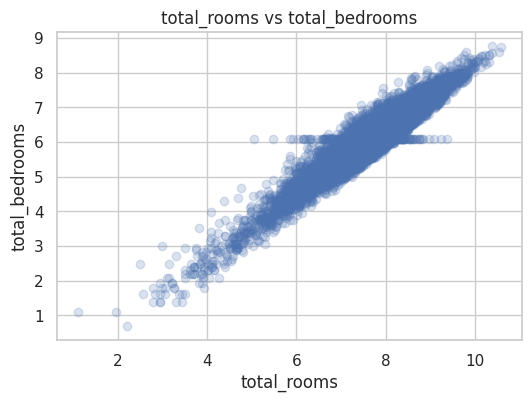

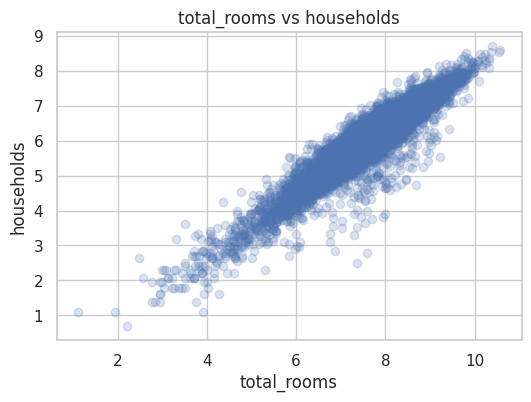

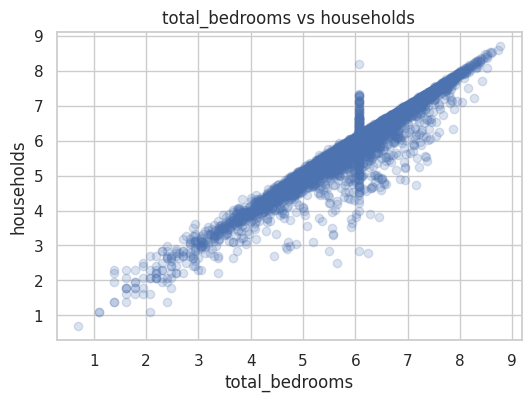

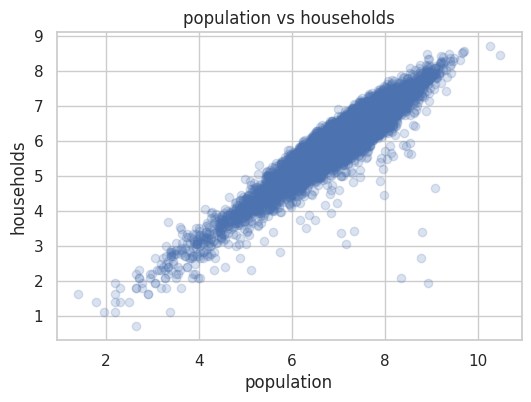

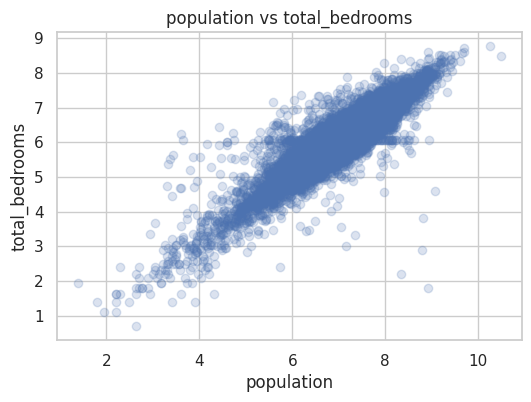

In [ ]:
pairs = [
    ('total_rooms', 'total_bedrooms'),
    ('total_rooms', 'households'),
    ('total_bedrooms', 'households'),
    ('population', 'households'),
    ('population', 'total_bedrooms')
]

for x, y in pairs:
    plt.figure(figsize=(6,4))
    plt.scatter(df[x], df[y], alpha=0.2)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.show()

These variables have multicollinearity,  they contain overlapping information about housing size and population.

In [ ]:
ocean_proximity_dummies = pd.get_dummies(df['ocean_proximity'], prefix='ocean_proximity', drop_first=True)
ocean_proximity_dummies = ocean_proximity_dummies.astype(int)
# Add new columns to the DataFrame
df = pd.concat([df, ocean_proximity_dummies], axis=1)
df.drop('ocean_proximity', axis=1, inplace=True)

df_regression = df.drop('income_cat', axis=1)

price_cap = df_regression['median_house_value'].quantile(0.99)
asheville_df = df_regression[df_regression['median_house_value'] <= price_cap]

Categorical variable ocean_proxmity convereted to dummmy variable.

Since the original dataframe (df) included a non-numeric column (income_cat), a new dataframe for future regression modeling is created. Then, to remove the outliers in median house value, the data is isolated to 99th percentile to limit the influence of outliers in our model.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Normalization, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
features = ['longitude', 'latitude','housing_median_age', 'total_rooms','median_income','ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY']
target = 'median_house_value'
X = df_regression[features]
y = df_regression[target]
y=y/100000
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

norm_layer = Normalization()
norm_layer.adapt(X_train.values)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    norm_layer,
    Dense(64, activation='relu'),
    Dense(1)])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    verbose= 1
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.0734 - mae: 0.7210 - val_loss: 0.5668 - val_mae: 0.5329
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5129 - mae: 0.5136 - val_loss: 0.5120 - val_mae: 0.5079
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4794 - mae: 0.4992 - val_loss: 0.4960 - val_mae: 0.5008
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4663 - mae: 0.4903 - val_loss: 0.4891 - val_mae: 0.4997
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4595 - mae: 0.4861 - val_loss: 0.4988 - val_mae: 0.5151
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4639 - mae: 0.4841 - val_loss: 0.4808 - val_mae: 0.4843
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4499 - mae: 0.4782 - val_loss: 0.4750 - val_mae: 0.4841
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4432 - mae: 0.4747 - val_loss: 0.4683 - val_mae: 0.4884
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

For machine learning, remove variables with multicollinearity from features and set a target for the model to run upon.

Scale the data down by 100,000 so that the model isn't overwhelmed by large numbers.

Train the model on 100 epochs to observe the graph's learning process to avoid underfitting/overfitting.

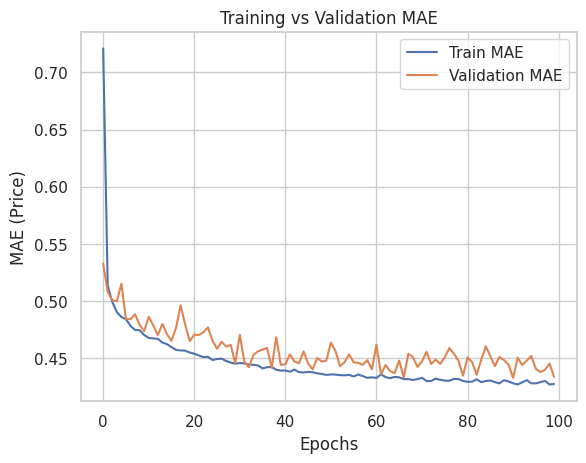

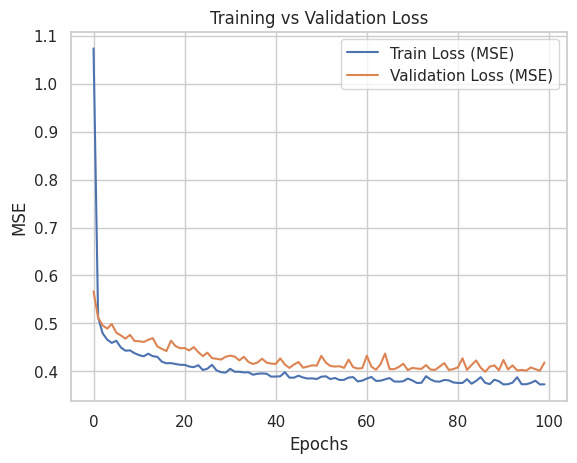

In [ ]:
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE (Price)')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In both plots, it displays that the model learns quickly through first 20 epochs, identifying relations between variables.

The lines flatten out through rest of the epochs without moving further away from each other, suggesting that the model dosn't have a problem with overfitting.

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: ${(test_mae*100000):.2f}")
print(f"Test Loss (MSE): ${test_loss:.2f}")
print(f"Test RMSE ${((np.sqrt(test_loss))*100000):.2f}")
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.2f}")

Test MAE: $43231.96
Test Loss (MSE): $0.42
Test RMSE $65052.77
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R² Score: 0.68


Mean Absolute Error (MAE) displays the the model's price predictions are off by $43452.09 on average.

Test loss (Mean Squared Error) is converted to Root Mean Squared Error (RMSE), then unscaled. RMSE of $63016.24 is higher than the MAE, suggesting a few presence of outliers that pulled the average up.

The R^2 of 0.70 means that the model's features explain 70% of the variance in California house prices.

# Checking whether `median_house_value` is skewed enough to justify a log transform.

In [ ]:
# Target log-transform check using existing dataframe from above
if 'df_regression' in globals():
    df_target = df_regression.copy()
elif 'df' in globals():
    df_target = df.copy()
else:
    raise NameError('Run the earlier data-loading/preprocessing cells first to create df or df_regression.')

raw_target_skew = df_target['median_house_value'].skew()
log_target = np.log1p(df_target['median_house_value'])
log_target_skew = log_target.skew()

print(f'Raw target skew: {raw_target_skew:.3f}')
print(f'Log target skew: {log_target_skew:.3f}')

if abs(log_target_skew) < abs(raw_target_skew):
    print('Inference: log transform improves symmetry, so it is a good next step for regression.')
else:
    print('Inference: log transform does not improve skew much, so keep the raw target or test both.')

Raw target skew: 0.978
Log target skew: -0.173
Inference: log transform improves symmetry, so it is a good next step for regression.


# Final Preprocessing and Baseline Regression (Log Target)

This block adds new features:
*   bedrooms_per_household
*   rooms_per_household
*   population_per_household

It creates a log target column: median_house_value_log and removes highly correlated original columns

Then it It trains a baseline linear regression model and creates a final dataset for further processing - df_final




In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # <-- ADD THIS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [ ]:
# Feature engineering
df_final = df_regression.copy()
if 'bedrooms_per_household' not in df_final.columns:
    df_final['bedrooms_per_household'] = df_final['total_bedrooms'] / df_final['households']
if 'rooms_per_household' not in df_final.columns:
    df_final['rooms_per_household'] = df_final['total_rooms'] / df_final['households']
if 'population_per_household' not in df_final.columns:
    df_final['population_per_household'] = df_final['population'] / df_final['households']

df_final['median_house_value_log'] = np.log1p(df_final['median_house_value'])

# Keep engineered ratios; drop highly correlated original predictors if needed
corr = df_final.drop(columns=['median_house_value', 'median_house_value_log']).corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_candidates = [c for c in ['total_rooms', 'total_bedrooms', 'population', 'households'] if c in upper.columns and any(upper[c] > 0.85)]
df_final = df_final.drop(columns=drop_candidates, errors='ignore')

X = df_final.drop(columns=['median_house_value', 'median_house_value_log'])
y = df_final['median_house_value_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler(); X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Dropped correlated originals:', drop_candidates)
print(f'Log-space R2: {r2_score(y_test, y_pred):.4f}')
print(f'Log-space RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'Dollar MAE: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred)):,.2f}')
print('Output dataframe for continuation: df_final, shape =', df_final.shape)




Dropped correlated originals: ['total_bedrooms', 'population', 'households']
Log-space R2: 0.6510
Log-space RMSE: 0.3365
Dollar MAE: $51,723.27
Output dataframe for continuation: df_final, shape = (20640, 14)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:

X_all = df_final.drop(columns=['median_house_value', 'median_house_value_log'])
y_all = df_final['median_house_value_log']

print('Feature columns:', X_all.columns.tolist())
print('Observations   :', len(X_all))


Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'bedrooms_per_household', 'rooms_per_household', 'population_per_household']
Observations   : 20640


In [ ]:
def checking_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["feature"] = dataframe.columns
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i)
                       for i in range(len(dataframe.columns))]
    return vif_data.sort_values(by=['VIF'], ascending=False)

X_train_ols, X_test_ols, y_train_ols, y_test_ols = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

vif = checking_vif(X_train_ols)
print(vif)

                       feature          VIF
0                    longitude  3205.329631
9       bedrooms_per_household  1593.486259
10         rooms_per_household  1078.585260
1                     latitude   988.395248
11    population_per_household   368.921205
3                  total_rooms   217.536840
4                median_income    11.554877
2           housing_median_age     7.916484
5       ocean_proximity_INLAND     2.863875
7     ocean_proximity_NEAR BAY     1.677101
8   ocean_proximity_NEAR OCEAN     1.305560
6       ocean_proximity_ISLAND     1.001694


In [ ]:
cols_to_drop = [
    'longitude',
    'latitude',
    'total_rooms',
    'bedrooms_per_household',
    'rooms_per_household',
    'population_per_household'
]

X_train_ols = X_train_ols.drop(columns=cols_to_drop)
X_test_ols = X_test_ols.drop(columns=cols_to_drop)


In [ ]:
vif_new = checking_vif(X_train_ols)
print(vif_new)

                      feature       VIF
0          housing_median_age  3.289220
1               median_income  2.889668
2      ocean_proximity_INLAND  1.392808
4    ocean_proximity_NEAR BAY  1.308324
5  ocean_proximity_NEAR OCEAN  1.233657
3      ocean_proximity_ISLAND  1.000789


In [ ]:
X_train_sm = sm.add_constant(X_train_ols)
model = sm.OLS(y_train_ols, X_train_sm).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     median_house_value_log   R-squared:                       0.617
Model:                                OLS   Adj. R-squared:                  0.617
Method:                     Least Squares   F-statistic:                     4435.
Date:                    Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                            13:14:43   Log-Likelihood:                -6189.9
No. Observations:                   16512   AIC:                         1.239e+04
Df Residuals:                       16505   BIC:                         1.245e+04
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

The OLS regression model explains approximately 61.7% of the variance in median house value, as indicated by the R-squared value of 0.617. The model is statistically significant overall, with an F-statistic of 4435 and a p-value of 0.00. All predictors have p-values below 0.05, indicating that they are statistically significant contributors to the model. Median income has the strongest positive effect on housing prices, while inland locations are associated with significantly lower values compared to coastal regions.

In [ ]:
# Extract and report key OLS metrics
print("="*70)
print("OLS MODEL PERFORMANCE METRICS")
print("="*70)
print(f"R-squared:        {model.rsquared:.4f}")
print(f"Adjusted R-sq:    {model.rsquared_adj:.4f}")
print(f"F-statistic:      {model.fvalue:.2f}")
print(f"Prob (F-stat):    {model.f_pvalue:.2e}")
print(f"Observations:     {model.nobs}")
print("="*70)

OLS MODEL PERFORMANCE METRICS
R-squared:        0.6172
Adjusted R-sq:    0.6171
F-statistic:      4435.25
Prob (F-stat):    0.00e+00
Observations:     16512.0


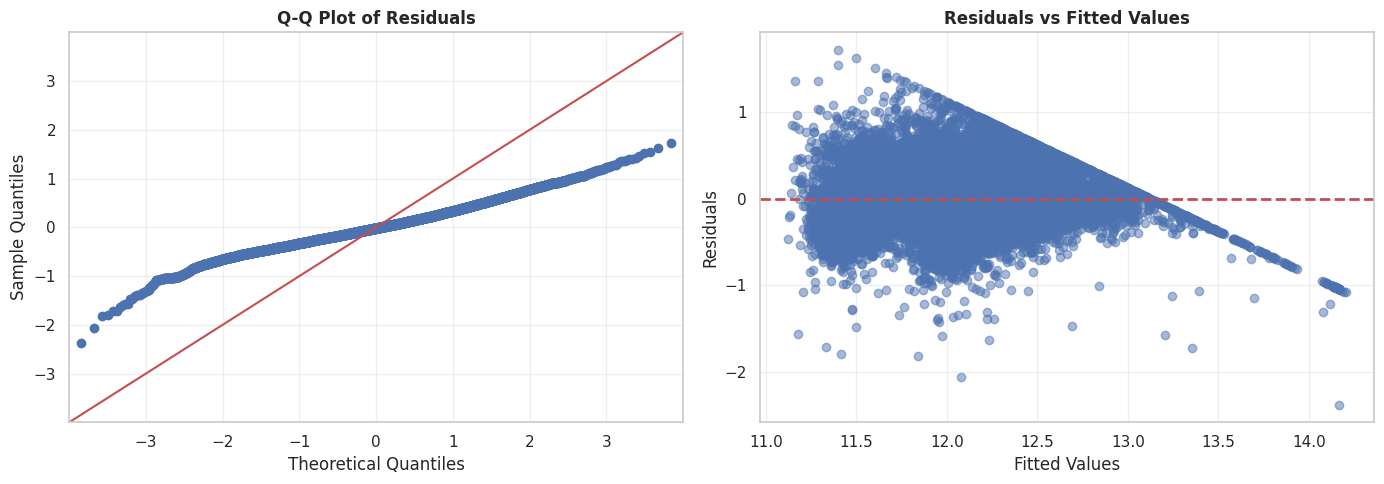


Residual Diagnostics:
Mean of residuals: 0.000000 (should be close to 0)
Std dev of residuals: 0.3520


In [ ]:
# Residual diagnostics: Q-Q plot and Residuals vs Fitted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot
residuals = model.resid
ProbPlot(residuals).qqplot(ax=axes[0], line='45')
axes[0].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Sample Quantiles')
axes[0].grid(True, alpha=0.3)

# Residuals vs Fitted
fitted_values = model.fittedvalues
axes[1].scatter(fitted_values, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResidual Diagnostics:")
print(f"Mean of residuals: {residuals.mean():.6f} (should be close to 0)")
print(f"Std dev of residuals: {residuals.std():.4f}")

In [ ]:
# Feature importance: OLS Coefficients with interpretation
print("\n" + "="*90)
print("OLS COEFFICIENTS (FEATURE IMPORTANCE)")
print("="*90)
coef_df = pd.DataFrame({
    'Feature': model.params.index,
    'Coefficient': model.params.values,
    'Std Error': model.bse.values,
    'P-value': model.pvalues.values,
    't-statistic': model.tvalues.values
}).round(6)

print(coef_df.to_string(index=False))
print("="*90)
print("\nInterpretation (log-transformed target):")
print("  • Coefficients represent log-unit changes in median_house_value.")
print("  • Multiply by 100 to get approximate % change in price per unit increase.")
print("  • Starred features (p < 0.05) are statistically significant.")
for idx, row in coef_df.iterrows():
    sig = "***" if row['P-value'] < 0.001 else "**" if row['P-value'] < 0.01 else "*" if row['P-value'] < 0.05 else "ns"
    if row['Feature'] != 'const':
        pct_change = row['Coefficient'] * 100
        print(f"  {row['Feature']:30s}: {pct_change:+.2f}% per unit {sig}")


OLS COEFFICIENTS (FEATURE IMPORTANCE)
                   Feature  Coefficient  Std Error  P-value  t-statistic
                     const    11.527797   0.010995 0.000000  1048.418353
        housing_median_age     0.001759   0.000233 0.000000     7.546546
             median_income     0.169681   0.001509 0.000000   112.427010
    ocean_proximity_INLAND    -0.503343   0.006704 0.000000   -75.075500
    ocean_proximity_ISLAND     0.719013   0.176121 0.000045     4.082492
  ocean_proximity_NEAR BAY     0.040706   0.009354 0.000014     4.351497
ocean_proximity_NEAR OCEAN     0.035431   0.008744 0.000051     4.052186

Interpretation (log-transformed target):
  • Coefficients represent log-unit changes in median_house_value.
  • Multiply by 100 to get approximate % change in price per unit increase.
  • Starred features (p < 0.05) are statistically significant.
  housing_median_age            : +0.18% per unit ***
  median_income                 : +16.97% per unit ***
  ocean_proximity_IN

 Check all four OLS assumptions (mean of residuals ≈ 0, no heteroscedasticity, linearity, normality of errors)

In [ ]:
# ── Assumption 1: Mean of Residuals ≈ 0 ──────────────────────────────────
residuals = model.resid
mean_resid = residuals.mean()
print(f"Mean of residuals: {mean_resid:.8f}")
if abs(mean_resid) < 1e-5:
    print("PASSED — mean is effectively zero (OLS property guaranteed).")
else:
    print("WARNING — mean is not close to zero. Check model specification.")


Mean of residuals: 0.00000000
PASSED — mean is effectively zero (OLS property guaranteed).


In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_lm, bp_p, fvalue, f_p = het_breuschpagan(residuals, model.model.exog)
print("Breusch-Pagan test for heteroscedasticity")
print(f"  LM statistic : {bp_lm:.4f}")
print(f"  p-value      : {bp_p:.4e}")
if bp_p < 0.05:
    print("FAILED — evidence of heteroscedasticity (p < 0.05).")
    print("   The log-transform on the target already reduces this; consider")
    print("   robust standard errors (HC3) or weighted least squares.")
else:
    print("PASSED — no significant heteroscedasticity detected.")


Breusch-Pagan test for heteroscedasticity
  LM statistic : 305.2580
  p-value      : 6.1093e-63
FAILED — evidence of heteroscedasticity (p < 0.05).
   The log-transform on the target already reduces this; consider
   robust standard errors (HC3) or weighted least squares.


The Breusch-Pagan test detected heteroscedasticity in our model, meaning the prediction errors are not equally spread across all house price ranges

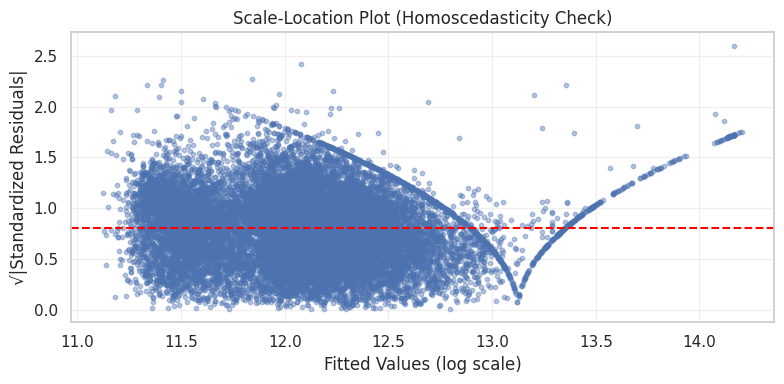

In [ ]:

fitted = model.fittedvalues
std_resid = residuals / residuals.std()

plt.figure(figsize=(8, 4))
plt.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.4, s=10)
plt.axhline(y=np.sqrt(np.abs(std_resid)).mean(), color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Fitted Values (log scale)')
plt.ylabel('√|Standardized Residuals|')
plt.title('Scale-Location Plot (Homoscedasticity Check)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Scale-Location plot visually confirms the heteroscedasticity we detected earlier. If everything were ideal, the blue line would be flat and horizontal. Instead it dips and curves, meaning the model's errors are not evenly spread it performs better for mid-range homes and worse at the extremes.

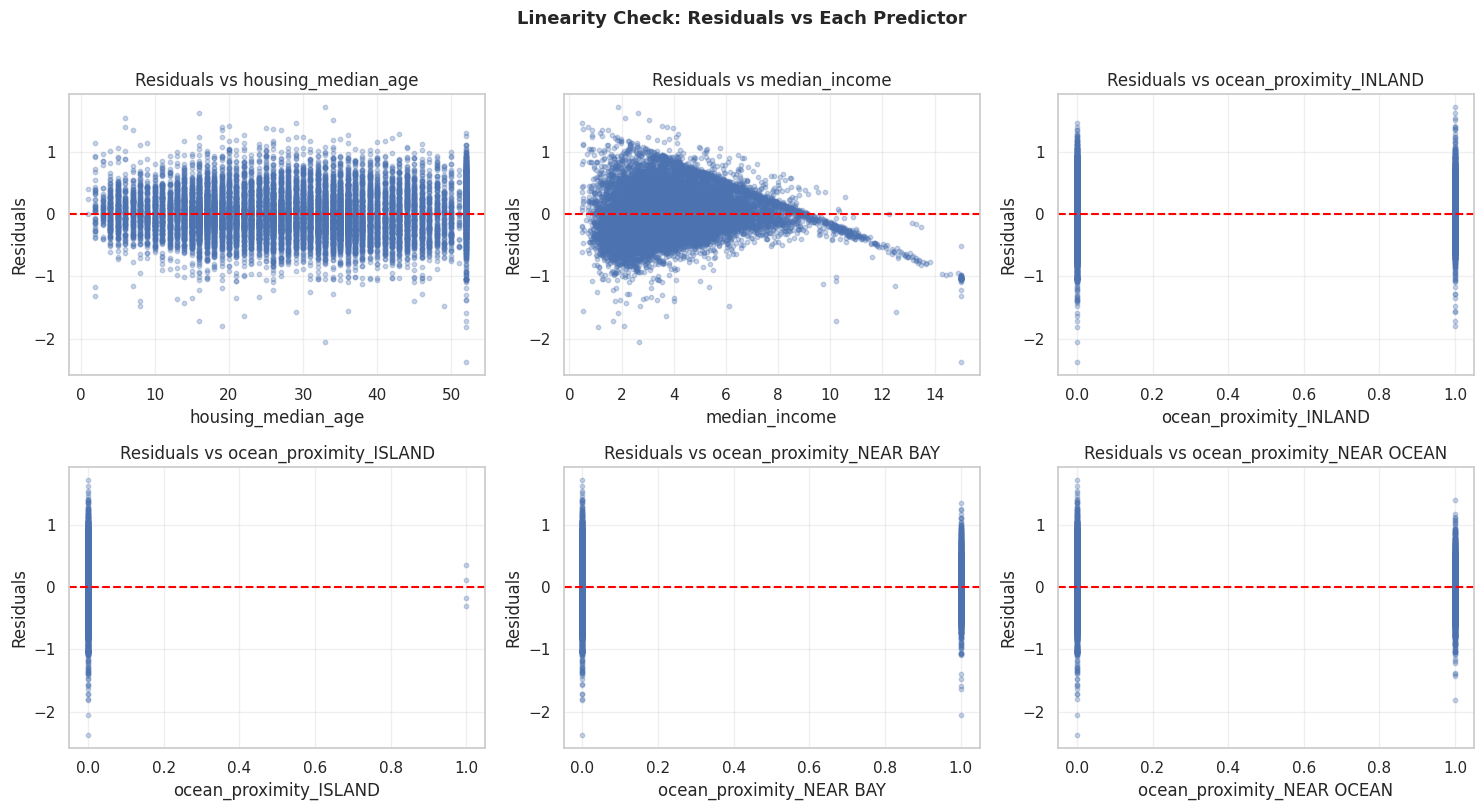

In [ ]:
feature_cols = X_train_ols.columns.tolist()
n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(X_train_ols[col], residuals, alpha=0.3, s=10)
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(f'Residuals vs {col}')
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Linearity Check: Residuals vs Each Predictor', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

These plots check whether each predictor has a linear relationship with house prices. Ideally the dots should be randomly scattered above and below the red line with no clear pattern. Housing median age looks good, the dots are evenly spread around zero. Median income shows a slight funnel shape, meaning the model is less accurate for very high income areas, which ties back to the heteroscedasticity we already addressed. The four ocean proximity variables only have two columns of dots (0 or 1) because they are dummy variables, so their scatter pattern is expected and not a concern. Overall the linearity assumption is reasonably satisfied.

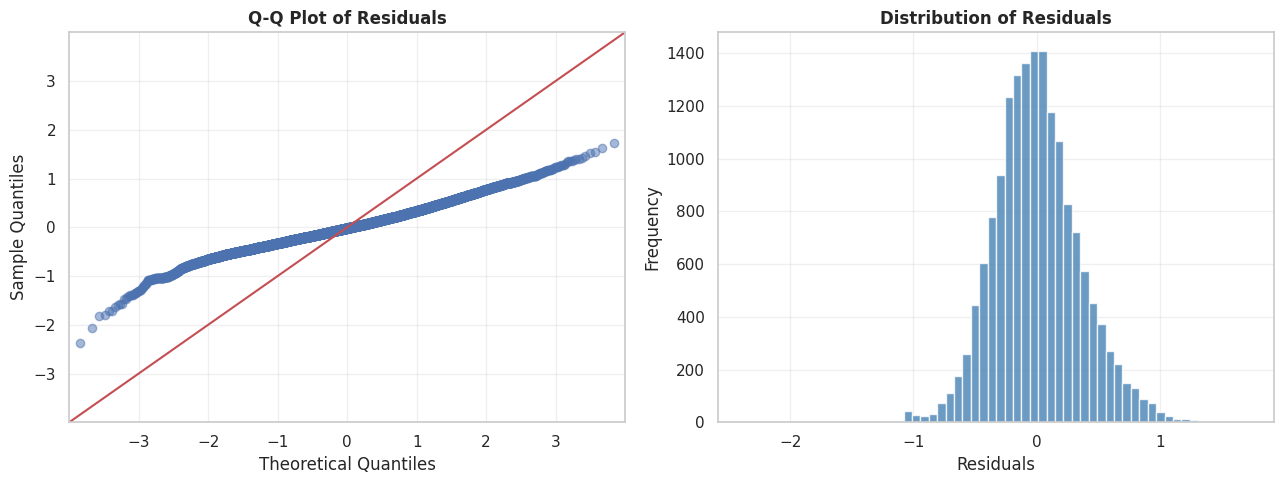

Shapiro-Wilk test (n=2000 sample): W=0.9932, p=5.4754e-08
Residuals are not perfectly normal (common for large datasets).
   Central Limit Theorem ensures inference is still approximately valid.


In [ ]:
from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ProbPlot(residuals).qqplot(ax=axes[0], line='45', alpha=0.5)
axes[0].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Sample Quantiles')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=60, edgecolor='white', color='steelblue', alpha=0.8)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Shapiro-Wilk on a sample (full dataset too large)
sample = residuals.sample(2000, random_state=42)
stat, p_sw = stats.shapiro(sample)
print(f"Shapiro-Wilk test (n=2000 sample): W={stat:.4f}, p={p_sw:.4e}")
if p_sw < 0.05:
    print("Residuals are not perfectly normal (common for large datasets).")
    print("   Central Limit Theorem ensures inference is still approximately valid.")
else:
    print("Residuals are approximately normal.")


These plots check whether our model's errors are normally distributed. The Q-Q plot shows the dots follow the red line well in the middle but drift off at both ends, meaning our model occasionally makes larger errors than expected, particularly for very cheap or very expensive California homes. The histogram shows the errors are roughly bell-shaped and centered around zero, which is good. The slight skew is likely caused by the $500,000 price cap in the dataset, which cuts off the upper end of the distribution.